## Function 2

## Check sys.path

In [1]:
# Checking that PYTHONPATH has been set to include local modules and included with sys.path

import os
try:
    print(f'PYTHONPATH:\n{os.environ['PYTHONPATH'].split(os.pathsep)}')
except KeyError:
    pass

import sys
print(f'\nsys.path:\n{'\n'.join(sys.path)}')

PYTHONPATH:
['C:\\Users\\antho\\Git\\LearningPython\\']

sys.path:
C:\Users\antho\Git\LearningPython
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\python314.zip
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\DLLs
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages


## Imports

In [2]:
# Load extension to auto re-import script changes without having to restart Python kernel 
%load_ext autoreload

# Set autoreload = 2 (reloads everything before every cell execution)
%autoreload 2

# Import scripts common across all BBOFunction notebooks. '%run' ensures variables/imports become part of this notebook's namespace
%run imports.py

## Function 2 Description

*Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum.*

*To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.*

## BBO parameters

In [3]:
func_no = 2
sub_week = 13

display(Markdown(f'**function number:** {func_no}'))
display(Markdown(f'**submission week:** {sub_week}'))

**function number:** 2

**submission week:** 13

## Load data

In [4]:
initial_len, y_pred, x_dim, x_col_names, df = data_helper.get_data(func_no, sub_week)

initial data points: 10
initial max: 0.6112052157614438
submission data points: 12
current max: 0.6761883182041306 (from submission week: 12)
x_dim: 2


<br>**DataFrame:**

          x1        x2         y
21  0.706935  0.270295  0.676188
13  0.706735  0.270095  0.632227
16  0.697758  0.000000  0.628924
9   0.702637  0.926564  0.611205
17  0.700267  0.000000  0.593367
20  0.705848  0.999999  0.588176
18  0.701683  0.065006  0.586085
12  0.692179  0.921078  0.568726
15  0.725799  0.205449  0.568246
0   0.665800  0.123969  0.538996
19  0.709000  0.280000  0.525525
1   0.877791  0.778628  0.420586
3   0.845275  0.711120  0.293993
6   0.438166  0.685018  0.244619
4   0.454647  0.290455  0.214965
10  0.804950  0.323123  0.102574
11  0.795131  0.963820  0.097248
7   0.341750  0.028698  0.038749
5   0.577713  0.771973  0.023106
14  0.952089  0.000000 -0.012982
8   0.338648  0.213867 -0.013858
2   0.142699  0.349005 -0.065624


### Manually omit columns or other data amends (if desired)

## Distance between x points

In [5]:
dists, min_dist, max_dist = distance_helper.distances_between_points(x = df[x_col_names].values)

#display(Markdown('**Distances between x points:**'))
#for row in dists:
#    print(f'{row}')

display(Markdown(f'**min_dist:** {min_dist}'))
display(Markdown(f'**max_dist:** {max_dist}'))

**min_dist:** 0.000283

**max_dist:** 1.039235

## Tune Gaussian Process surrogate model

### Setup hyperparameters to trial (kernels, x_tansform and y_transform)

In [6]:
kernels = gaussian_process_helper.get_kernels(x_dim)

print(kernels.keys())

dict_keys(['Matern 2.5', 'Matern 1.5', 'Matern 0.5', 'RBF', 'Rational Quad', 'Periodic', 'Locally Periodic', 'Linear + RBF', 'Matern 2.5 + WhiteK', 'Matern 1.5 + WhiteK', 'Matern 0.5 + WhiteK', 'RBF + WhiteK', 'Rational Quad + WhiteK', 'Periodic + WhiteK', 'Locally Periodic + WhiteK', 'Linear + RBF + WhiteK', 'Local Sens + Mat 2.5 + WhiteK', 'Ridge + RQ + WhiteK', 'Local Sens + Ridge + Mat 2.5 + WhiteK'])


In [7]:
y_transforms = transform_helper.get_y_transformers()

print(y_transforms.keys())

dict_keys(['none', 'scaled', 'power', 'pow-scaled', 'logshift', 'logshift-scaled'])


In [8]:
x_transforms = transform_helper.get_x_transformers()

print(x_transforms.keys())

dict_keys(['none', 'scaled'])


### Manually override hyperparameter options (if desired)

### Perform the hyperparameter tuning

In [9]:
df_tuning_results, model_dict = gaussian_process_helper.tune_gaussian_process_surrogate(
    df = df,
    x_col_names = x_col_names,
    kernels = kernels,
    y_transforms = y_transforms,
    x_transforms = x_transforms,
)


Matern 2.5, x:none, y:none...
         y_t        mean_t   resid_t     std_t        y_pred
21  0.676188  6.344957e-01 -0.041693  0.024506  6.344957e-01
13  0.632227  6.718780e-01  0.039651  0.024524  6.718780e-01
16  0.628924  5.912846e-01 -0.037640  0.035189  5.912846e-01
9   0.611205  2.166414e-01 -0.394564  0.388714  2.166414e-01
17  0.593367  6.267174e-01  0.033351  0.035189  6.267174e-01
20  0.588176  7.438812e-08 -0.588176  0.420410  7.438812e-08
18  0.586085  2.857048e-11 -0.586085  0.420410  2.857048e-11
12  0.568726  2.328229e-01 -0.335903  0.388714  2.328229e-01
15  0.568246 -3.293686e-10 -0.568246  0.420410 -3.293686e-10
0   0.538996  1.959855e-11 -0.538996  0.420410  1.959855e-11
19  0.525525  1.539094e-01 -0.371615  0.415337  1.539094e-01
1   0.420586  5.745047e-08 -0.420586  0.420410  5.745047e-08
3   0.293993  1.193655e-10 -0.293993  0.420410  1.193655e-10
6   0.244619  1.431502e-10 -0.244619  0.420410  1.431502e-10
4   0.214965  8.389112e-06 -0.214956  0.420410  8.3891

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__periodicity is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t        mean_t   resid_t     std_t    y_pred
21  0.968876  8.786631e-01 -0.090213  0.039503  0.624661
13  0.892765  9.829893e-01  0.090225  0.041288  0.684983
16  0.886874  4.974669e-01 -0.389407  0.333905  0.456582
9   0.854824  3.694930e-01 -0.485331  0.452091  0.417077
17  0.821786  9.513502e-01  0.129564  0.154498  0.670951
20  0.812022  1.200267e+00  0.388245  0.443205  0.877324
18  0.808069  7.181983e-01 -0.089871  0.183571  0.546224
12  0.774802  5.720893e-01 -0.202713  0.923534  0.626431
15  0.773872 -3.863423e-03 -0.777735  0.987384  0.380666
0   0.715891  5.878341e-08 -0.715891  0.987404  0.382136
19  0.688342  1.064421e+00  0.376079  0.297255  0.755621
1   0.452440  2.297984e-11 -0.452440  0.987404  0.382136
3   0.100532  1.034185e-10 -0.100532  0.987404  0.382136
6  -0.065531 -5.013908e-04  0.065030  0.987400  0.381945
4  -0.175861 -1.868334e-04  0.175674  0.987400  0.382064
10 -0.699436 -6.520465e-02  0.634231  0.983457  0.356927
11 -0.729975 -6.247673e-02  0.6

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
21  0.676188  0.584197 -0.091991  0.057984  0.584197
13  0.632227  0.607420 -0.024807  0.058111  0.607420
16  0.628924  0.582244 -0.046680  0.066333  0.582244
9   0.611205  0.544893 -0.066313  0.069911  0.544893
17  0.593367  0.615461  0.022095  0.066145  0.615461
20  0.588176  0.404170 -0.184006  0.194861  0.404170
18  0.586085  0.578493 -0.007593  0.133393  0.578493
12  0.568726  0.611979  0.043253  0.074536  0.611979
15  0.568246  0.651632  0.083386  0.164128  0.651632
0   0.538996  0.463037 -0.075959  0.164550  0.463037
19  0.525525  0.624505  0.098981  0.062480  0.624505
1   0.420586  0.303295 -0.117291  0.202672  0.303295
3   0.293993  0.379306  0.085313  0.201075  0.379306
6   0.244619  0.153825 -0.090795  0.260994  0.153825
4   0.214965  0.142002 -0.072963  0.245632  0.142002
10  0.102574  0.357299  0.254725  0.236928  0.357299
11  0.097248  0.532448  0.435201  0.221814  0.532448
7   0.038749  0.108099  0.069350  0.251006  0.

...

         y_t    mean_t   resid_t     std_t    y_pred
21  0.927350  0.764291 -0.163059  0.097938  0.578697
13  0.851591  0.802054 -0.049537  0.098075  0.601600
16  0.845988  0.762971 -0.083017  0.111541  0.577522
9   0.816134  0.708110 -0.108024  0.114662  0.543442
17  0.786435  0.816790  0.030355  0.111294  0.610107
20  0.777861  0.513474 -0.264387  0.267357  0.404164
18  0.774415  0.757786 -0.016630  0.189868  0.571219
12  0.745998  0.804479  0.058481  0.121752  0.602418
15  0.745218  0.840112  0.094894  0.231138  0.619043
0   0.698118  0.595947 -0.102171  0.231320  0.464465
19  0.676748  0.840928  0.164181  0.103692  0.624680
1   0.517220  0.367190 -0.150030  0.277866  0.294032
3   0.341071  0.469725  0.128654  0.275597  0.371732
6   0.277174  0.198246 -0.078928  0.350274  0.135693
4   0.240086  0.184186 -0.055900  0.330570  0.128066
10  0.108278  0.481290  0.373012  0.321521  0.373825
11  0.102374  0.684256  0.581883  0.303783  0.516251
7   0.039562  0.141389  0.101828  0.336831  0.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
21  0.676188  0.591424 -0.084764  0.044764  0.591424
13  0.632227  0.599466 -0.032760  0.044730  0.599466
16  0.628924  0.596350 -0.032575  0.038470  0.596350
9   0.611205  0.588024 -0.023181  0.048746  0.588024
17  0.593367  0.622536  0.029169  0.037540  0.622536
20  0.588176  0.594080  0.005903  0.051416  0.594080
18  0.586085  0.616140  0.030054  0.046904  0.616140
12  0.568726  0.602035  0.033310  0.055439  0.602035
15  0.568246  0.519071 -0.049176  0.077183  0.519071
0   0.538996  0.456832 -0.082164  0.114654  0.456832
19  0.525525  0.617367  0.091843  0.045269  0.617367
1   0.420586  0.270487 -0.150099  0.128558  0.270487
3   0.293993  0.292757 -0.001236  0.104357  0.292757
6   0.244619  0.195353 -0.049266  0.095385  0.195353
4   0.214965  0.237409  0.022445  0.096267  0.237409
10  0.102574  0.122650  0.020076  0.069522  0.122650
11  0.097248  0.121179  0.023931  0.076252  0.121179
7   0.038749 -0.002663 -0.041412  0.060309 -0.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
21  0.927350  0.782762 -0.144588  0.070607  0.590524
13  0.851591  0.795904 -0.055687  0.070557  0.598466
16  0.845988  0.792566 -0.053422  0.065052  0.596546
9   0.816134  0.779492 -0.036642  0.076847  0.588425
17  0.786435  0.831102  0.044667  0.063746  0.619637
20  0.777861  0.789709  0.011848  0.080603  0.594540
18  0.774415  0.821387  0.046972  0.073586  0.613693
12  0.745998  0.799373  0.053375  0.085592  0.600267
15  0.745218  0.688494 -0.056724  0.112574  0.531156
0   0.698118  0.596375 -0.101743  0.160682  0.469480
19  0.676748  0.823380  0.146632  0.071315  0.614921
1   0.517220  0.310319 -0.206902  0.176849  0.262153
3   0.341071  0.346585  0.005514  0.146346  0.292924
6   0.277174  0.212281 -0.064893  0.134803  0.186373
4   0.240086  0.270527  0.030441  0.135769  0.234141
10  0.108278  0.140288  0.032010  0.104504  0.126886
11  0.102374  0.141413  0.039040  0.113989  0.127091
7   0.039562  0.002602 -0.036959  0.093985 -0.

## Analytical Leave-One-Out Cross-Validation (LOOCV) Model Results 

In [10]:
# Sort df_tuning_results:
# Mean-Square_Error (MSE) - The "best" kernel is the one with the lowest MSE    
# Log-Marginal Likelihood (LML) - The "best" kernel is the one with the highest LML
sort_columns = [Y_SMSE_TOP, Y_SMSE, Z_SMSE, LML]
sort_orders  = [      True,   True,   True, False]

#sort_columns = [Y_SMSE, Z_SMSE, LML]
#sort_orders  = [  True,   True, False]

df_tuning_results_sorted = df_tuning_results.sort_values(by=sort_columns, ascending=sort_orders)

# Format numeric display columns
display_cols = [MODEL, Z_SMSE, Y_SMSE, Y_SMSE_TOP, LML, KERNEL_PARAMS ]
for col in display_cols:
    df_tuning_results_sorted[col] = df_tuning_results_sorted[col].apply(format_sig_figs)

print(df_tuning_results_sorted[display_cols].to_string(index=False))

                                                             Model    Z_SMSE    Y_SMSE Y_SMSE_TOP       LML                                                                                                                                                     Kernel_Params
                         Locally Periodic + WhiteK, x:none, y:none 0.0421482 0.0421482 0.00754636   21.8774                                          0.22**2 * RBF(len_scale=[0.0558, 1.94e+03]) * ExpSineSquared(len_scale=5.19, periodicity=0.0356) + WhiteK(noise=0.00138)
                    Matern 0.5 + WhiteK, x:none, y:logshift-scaled  0.500158  0.453066  0.0169526  -14.5718                                                                                           1.17**2 * Matern(len_scale=[0.164, 10], nu=0.5) + WhiteK(noise=0.00133)
                  Matern 0.5 + WhiteK, x:scaled, y:logshift-scaled  0.523766  0.445107  0.0171871  -15.8729                                                                                   

## LOOCV Detailed Results for best model (Optionally override auto selected best model)

In [11]:
best_model_name = df_tuning_results_sorted[MODEL].iloc[0]

# Manually overriding best_model (optional)
override_model_name = None

if not override_model_name is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding best model from "{best_model_name}" to "{override_model_name}"**</span>'))
    best_model_name = override_model_name
    
best_model_dict = model_dict[best_model_name]
best_model = best_model_dict[MODEL]
x_transform = best_model_dict[X_TRANSFORM]
y_transform = best_model_dict[Y_TRANSFORM]

display(Markdown(f'<br>**Best model:**<br>{best_model_name}'))

params_str = extract_optimised_kernel_params_str(best_model)
display(Markdown(f'**Optimised parameters:**'))
print(params_str) # Own print() since it contains **

best_loocv_results = best_model_dict[LOOCV]

# Add the best model LOOCV results to df for easier display 
for label, content in best_loocv_results.items():
    df[label] = content

display(Markdown(f'<br>**LOOCV Predictions using best model:**<br>'))
print(df)

<br>**Best model:**<br>Locally Periodic + WhiteK, x:none, y:none

**Optimised parameters:**

0.22**2 * RBF(len_scale=[0.0558, 1.94e+03]) * ExpSineSquared(len_scale=5.19, periodicity=0.0356) + WhiteK(noise=0.00138)


<br>**LOOCV Predictions using best model:**<br>

          x1        x2         y       y_t    mean_t   resid_t     std_t  \
21  0.706935  0.270295  0.676188  0.676188  0.629122 -0.047066  0.043290   
13  0.706735  0.270095  0.632227  0.632227  0.647911  0.015684  0.042908   
16  0.697758  0.000000  0.628924  0.628924  0.624326 -0.004598  0.019082   
9   0.702637  0.926564  0.611205  0.611205  0.606204 -0.005001  0.014876   
17  0.700267  0.000000  0.593367  0.593367  0.596528  0.003161  0.018894   
20  0.705848  0.999999  0.588176  0.588176  0.608287  0.020110  0.049479   
18  0.701683  0.065006  0.586085  0.586085  0.596811  0.010725  0.025733   
12  0.692179  0.921078  0.568726  0.568726  0.566408 -0.002318  0.015276   
15  0.725799  0.205449  0.568246  0.568246  0.552817 -0.015429  0.028601   
0   0.665800  0.123969  0.538996  0.538996  0.519760 -0.019236  0.083596   
19  0.709000  0.280000  0.525525  0.525525  0.568382  0.042857  0.036049   
1   0.877791  0.778628  0.420586  0.420586  0.327795 -0.092791  0.087710   
3   0.845275

## y and y_t (y transformed) plots

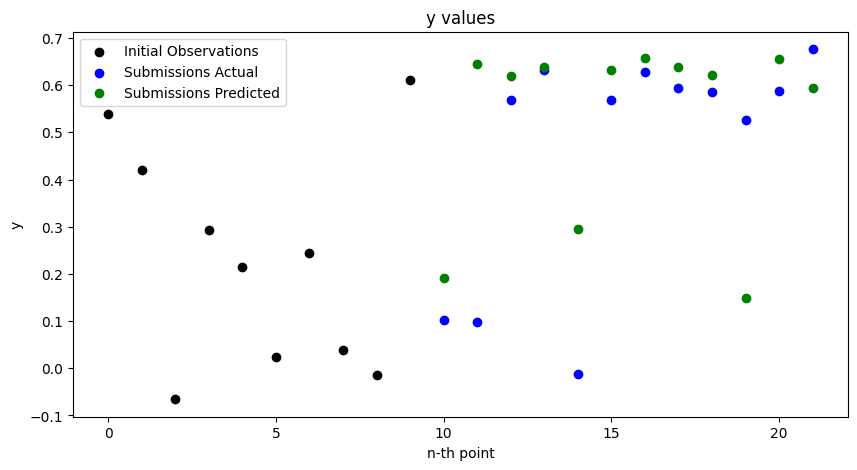

In [12]:
plot_helper.sequence_plot(df["y"], initial_len, y_pred)

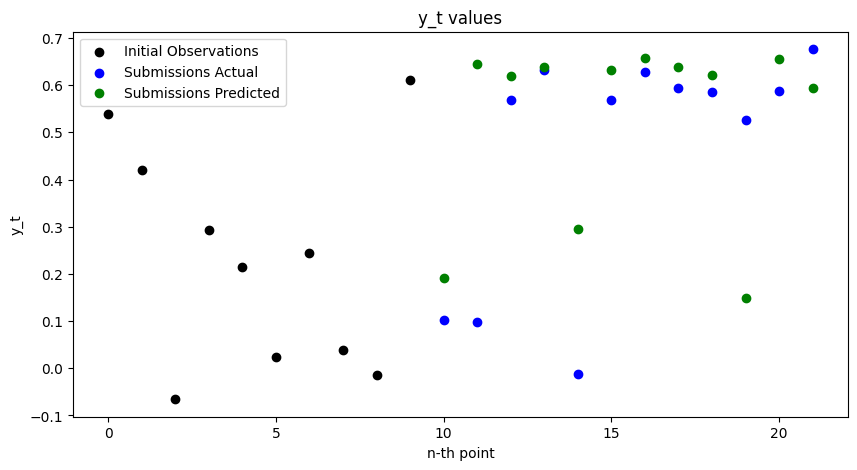

In [13]:
y_t_pred = y_transform.transform(y_pred)
plot_helper.sequence_plot(df["y_t"], initial_len, y_t_pred)

## Determine next evaluation point

### Create grid

In [14]:
x_grid = grid_helper.hypercube_grid([250, 250], x_col_names)

#print(x_grid[0:5])

len(x_grid): 63001


### Maximise UCB and EI acquisition functions

In [15]:
# Small xi (0.0 – 0.01) - Exploitation dominant
# Moderate xi (0.01 – 0.1) - Balanced
# Large xi (0.5+) Strong exploration
ei_xis = [ 2, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0 ]
ucb_betas = [ 10, 5, 2, 1, 0.5, 0.1, 0.05, 0.01, 0 ]
acq_fns = acquisition_fns_helper.get_acq_fns(df, y_transform, ei_xis = ei_xis, ucb_betas = ucb_betas)

# Bespoke bounds to force suggested next x near current x_best:
override_bounds = None # [(0.5, 0.9), (0.1, 0.4), ...]

if not override_bounds is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding acquisition function optimisation bounds to "{override_bounds}"**</span>'))

df_acq_results = acquisition_fns_helper.determine_next_eval_points(df, best_model, x_grid, x_col_names, x_transform, y_transform, x_dim, acq_fns, bounds = override_bounds, opt_trials=1000)

EI trans space (xi=2)...


C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\_gpr.py:490: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(


Acq Fn([0.    0.004]) = 3.5996849595932774e-35, distance: 0.34264086402500876, y_t_best: [-0.00224788], y_best: [-0.00224788]
EI trans space (xi=1)...
Acq Fn([0.    0.004]) = 8.200434368265593e-16, distance: 0.34264086402500876, y_t_best: [-0.00224788], y_best: [-0.00224788]
EI trans space (xi=0.5)...
Acq Fn([0.    0.004]) = 2.6213519394985943e-09, distance: 0.34264086402500876, y_t_best: [-0.00224788], y_best: [-0.00224788]
EI trans space (xi=0.1)...
Acq Fn([0.68440213 0.12099738]) = 0.00015244753909061048, distance: 0.018838427136175184, y_t_best: [0.62300796], y_best: [0.62300796]
EI trans space (xi=0.05)...
Acq Fn([0.70041892 0.19510783]) = 0.0015702707035679655, distance: 0.027405992053447462, y_t_best: [0.66545701], y_best: [0.66545701]
EI trans space (xi=0.01)...
Acq Fn([0.69881681 0.22732168]) = 0.0147106766075611, distance: 0.03473402543479053, y_t_best: [0.70089899], y_best: [0.70089899]
EI trans space (xi=0.005)...
Acq Fn([0.69881681 0.22732167]) = 0.019710676607528458, dist

### Display the acquisition function results

In [16]:
display(Markdown(f'<br>**EXISTING BEST:**'))
print(f'Actual y: {df['y'].iloc[0]}\nActual y_t: {df['y_t'].iloc[0]}\nx: {df[x_col_names].iloc[0].values}')

y_t_mean, y_t_std = best_model.predict(np.atleast_2d(df[x_col_names].iloc[0].values), return_std=True)
y_mean, y_std = y_transform.inverse_transform_dist(y_t_mean, y_t_std)

display(Markdown(f'<br>**Model\'s [{best_model_name}] prediction at x corresponding to the best y.**'))
print(f'NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.')
print(f'y_t_mean: {y_t_mean}, y_t_std: {y_t_std}\ny_mean: {y_mean}\n')

# Add a y_mean ranking
df_acq_results['y_mean rank'] = df_acq_results['y_mean'].rank(ascending=False, method='min').astype(int)

display(Markdown(f'<br>**FUNCTION {func_no} SUBMISSION WEEK {sub_week}:**<br>'))
print(df_acq_results.to_string(index=False))

<br>**EXISTING BEST:**

Actual y: 0.6761883182041306
Actual y_t: 0.6761883182041306
x: [0.706935 0.270295]


<br>**Model's [Locally Periodic + WhiteK, x:none, y:none] prediction at x corresponding to the best y.**

NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.
y_t_mean: [0.64163319], y_t_std: [0.04173287]
y_mean: [0.64163319]



<br>**FUNCTION 2 SUBMISSION WEEK 13:**<br>

                     acq_fn      ['x1', 'x2']  distance  y_t_mean    y_mean  y_mean rank
      EI trans space (xi=2) 0.000000-0.004000  0.342641 -0.002248 -0.002248           22
      EI trans space (xi=1) 0.000000-0.004000  0.342641 -0.002248 -0.002248           22
    EI trans space (xi=0.5) 0.000000-0.004000  0.342641 -0.002248 -0.002248           22
    EI trans space (xi=0.1) 0.684402-0.120997  0.018838  0.623008  0.623008           19
   EI trans space (xi=0.05) 0.700419-0.195108  0.027406  0.665457  0.665457           15
   EI trans space (xi=0.01) 0.698817-0.227322  0.034734  0.700899  0.700899            3
  EI trans space (xi=0.005) 0.698817-0.227322  0.034734  0.700899  0.700899           13
  EI trans space (xi=0.001) 0.698817-0.227322  0.034734  0.700899  0.700899            6
      EI trans space (xi=0) 0.698817-0.227322  0.034734  0.700899  0.700899            7
       EI orig space (xi=2) 0.988000-0.068000  0.076900 -0.116735 -0.116735           25
       EI orig space 

## Plot new point

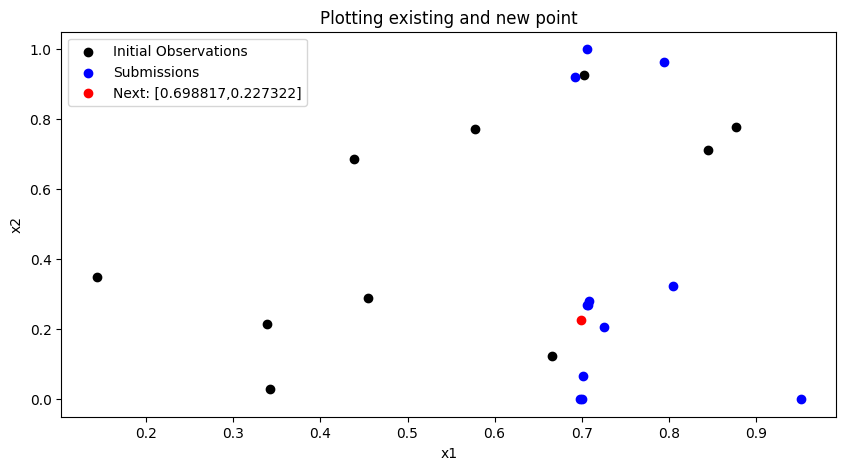

In [17]:
import matplotlib.pyplot as plt

x_best = [0.698817, 0.227322] # UCB trans space (beta=0)

df_index_sorted = df.sort_index()

x1 = df_index_sorted["x1"]
x2 = df_index_sorted["x2"]

plt.figure(figsize=(10, 5))
plt.scatter(x1[:initial_len], x2[:initial_len], c='k', label='Initial Observations')  # 'k' = black
plt.scatter(x1[initial_len:], x2[initial_len:], c='b', label='Submissions') # 'b' = blue
plt.scatter([x_best[0]], [x_best[1]], c='r', label=f'Next: [{x_best[0]:.6f},{x_best[1]:.6f}]')  
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title(f'Plotting existing and new point')
plt.show()

## Manually calculating the prediction at an x point (Helper method)